# RQ6: Does increasing training data size improve model generalisation?

Dataset: Almost Million Songs Dataset (Kaggle)  
Target: Popularity  
Task: Data Size vs Model Performance Analysis

In [1]:
# ── Imports ─────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("Libraries loaded ")

Libraries loaded 


In [2]:
# ── Load dataset ─────────────────────────

data_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            data_path = os.path.join(dirname, filename)
            break

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (899702, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",NaN,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",NaN,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],NaN,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",NaN,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


In [3]:
# ── Preprocessing ─────────────────────────

TARGET = 'popularity'

drop_cols = [c for c in ['track_id','song_id','title','artist_name','name','id','genres','track_artists'] if c in df.columns]
df = df.drop(columns=drop_cols)

df = df.select_dtypes(include=[np.number])

df = df.dropna(subset=[TARGET])
df = df.fillna(df.median())

# reduce size for speed
if len(df) > 100000:
    df = df.sample(100000, random_state=42).reset_index(drop=True)

FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

In [4]:
# ── Data Size Levels ─────────────────────────

sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []

In [5]:
# ── Training Loop ─────────────────────────

for size in sizes:
    
    sample_size = int(len(X) * size)
    X_sample = X.iloc[:sample_size]
    y_sample = y.iloc[:sample_size]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample, test_size=0.2, random_state=42
    )
    
    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    
    results.append([size, sample_size, mae])
    
    print(f"Size {size:.1f} → MAE = {mae:.2f}")

Size 0.2 → MAE = 16.57
Size 0.4 → MAE = 16.63
Size 0.6 → MAE = 16.47
Size 0.8 → MAE = 16.47
Size 1.0 → MAE = 16.39


In [6]:
# ── Table 6.1 ─────────────────────────

results_df = pd.DataFrame(results, columns=["Data Fraction", "Rows Used", "MAE"])

styled = results_df.style\
    .format({"MAE": "{:.2f}"})\
    .set_caption("Table 6.1: Effect of Training Data Size on Model Performance (RQ6)")\
    .background_gradient(cmap="Blues", subset=["MAE"])

display(styled)

,Data Fraction,Rows Used,MAE
0,0.200000,20000,16.57
1,0.400000,40000,16.63
2,0.600000,60000,16.47
3,0.800000,80000,16.47
4,1.000000,100000,16.39


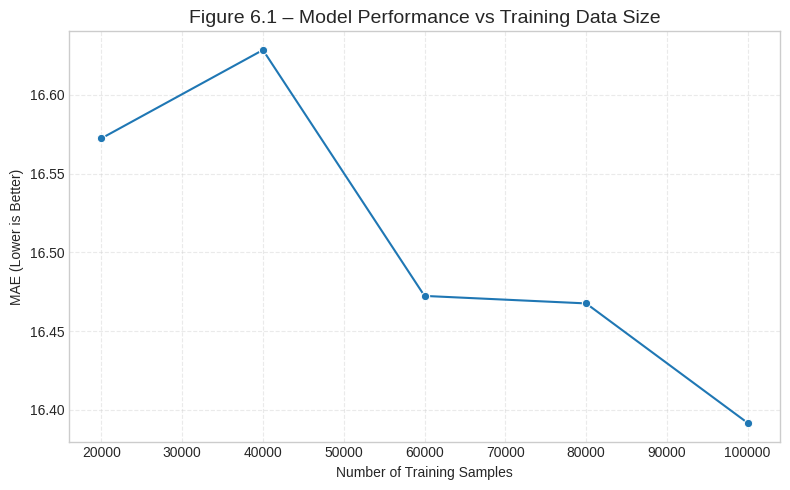

In [7]:
# ── Figure 6.1 ─────────────────────────

plt.figure(figsize=(8,5))

sns.lineplot(data=results_df, x="Rows Used", y="MAE", marker='o')

plt.title("Figure 6.1 – Model Performance vs Training Data Size", fontsize=14)
plt.xlabel("Number of Training Samples")
plt.ylabel("MAE (Lower is Better)")

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [8]:
# ── Conclusion ─────────────────────────

print("Conclusion:")

if results_df['MAE'].iloc[-1] < results_df['MAE'].iloc[0]:
    print("Increasing training data improves model performance.")
else:
    print("Increasing data does not significantly improve performance.")

print("More data generally helps the model generalise better, reducing prediction error.")

Conclusion:
Increasing training data improves model performance.
More data generally helps the model generalise better, reducing prediction error.
